In [2]:
# ─────────────────────────────────────────────
# 환경 준비 — 라이브러리 불러오기 + 한글 폰트 + 시드 고정
# ─────────────────────────────────────────────
# 필요 시 아래 주석을 해제해 설치하세요.
!pip install numpy pandas scikit-learn matplotlib seaborn -q

import platform
import warnings
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# 재현성: 같은 난수를 항상 같게 만듭니다.
np.random.seed(42)

# 한글 폰트 설정 (그래프 안 글자가 깨지지 않도록)
system = platform.system()
if system == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

print("준비 완료! 라이브러리 버전을 확인합니다.")
print("numpy :", np.__version__)
print("pandas:", pd.__version__)

준비 완료! 라이브러리 버전을 확인합니다.
numpy : 2.5.0
pandas: 3.0.3


In [3]:
# ─────────────────────────────────────────────
# 모두마켓 이번 달 주문 데이터 생성 — 자기완결적 스냅샷
# (지난 노드에서 다룬 오염 요소를 적당히 섞어 둡니다)
# ─────────────────────────────────────────────
np.random.seed(42)
n = 1500

regions = np.random.choice(["서울", "경기", "부산", "인천", "대구"], n, p=[0.4, 0.25, 0.15, 0.1, 0.1])
membership = np.random.choice(["basic", "silver", "gold", "vip"], n, p=[0.5, 0.25, 0.15, 0.1])
channels = np.random.choice(["web", "app", "app ", "APP"], n, p=[0.5, 0.4, 0.05, 0.05])
categories = np.random.choice(["패션", "뷰티", "식품", "가전", "도서"], n)

prices = np.random.choice([9900, 19900, 29900, 49900, 89900, 129900, 249900], n,
                          p=[0.2, 0.25, 0.2, 0.15, 0.1, 0.06, 0.04])
quantities = np.random.choice([1, 1, 1, 2, 2, 3], n)
amount = (prices * quantities).astype(float)

orders = pd.DataFrame({
    "order_id": [f"O{str(i).zfill(5)}" for i in range(1, n + 1)],
    "customer_age": np.random.normal(35, 9, n).round().astype(int),
    "region": regions,
    "membership": membership,
    "channel": channels,
    "category": categories,
    "price": prices.astype(float),
    "quantity": quantities,
    "amount": amount,
})

# 오염 심기: 결측·이상치·표기 혼재
orders.loc[np.random.choice(n, 60, replace=False), "amount"] = np.nan
orders.loc[np.random.choice(n, 30, replace=False), "customer_age"] = np.nan
orders.loc[5, "customer_age"] = 999             # 입력 실수성 이상치
orders.loc[8, "customer_age"] = -3              # 불가능한 음수
orders.loc[12, "quantity"] = 80                 # 비정상적으로 큰 주문
orders.loc[20, "region"] = " 서울 "             # 앞뒤 공백
orders.loc[21, "region"] = "Seoul"              # 영문 표기
orders.loc[40, "membership"] = "VIP"            # 대소문자 혼재

print("이번 달 주문 데이터 준비 완료:", orders.shape)
orders.head()

이번 달 주문 데이터 준비 완료: (1500, 9)


,order_id,customer_age,region,membership,channel,category,price,quantity,amount
0,O00001,30.0,서울,silver,app,패션,19900.0,1,NaN
1,O00002,24.0,대구,basic,app,가전,249900.0,3,749700.0
2,O00003,45.0,부산,basic,web,패션,19900.0,1,19900.0
3,O00004,24.0,경기,basic,app,뷰티,19900.0,1,NaN
4,O00005,41.0,서울,basic,app,패션,19900.0,1,19900.0


In [2]:
# 예제: 'map'이 가장 어울리는 자리 — dict 치환
gender_kr_to_num = {"M": 1, "F": 0}
sample_gender = pd.Series(["M", "F", "F", "M", "F"])

# map은 dict를 그대로 받습니다. 이게 가장 자연스러움.
print("map(dict):", sample_gender.map(gender_kr_to_num).tolist())

# 같은 일을 apply로 하려면 dict.get을 래핑해야 합니다(가독성 떨어짐).
print("apply(lambda):", sample_gender.apply(lambda x: gender_kr_to_num.get(x)).tolist())

map(dict): [1, 0, 0, 1, 0]
apply(lambda): [1, 0, 0, 1, 0]


In [3]:
# 예제: 속도 비교 — 10만 건에 '부가세 10% 더하기'
big = pd.Series(np.random.randint(1000, 100_000, 100_000).astype(float))

# (a) apply
start = time.time()
_ = big.apply(lambda x: x * 1.1)
t_apply = time.time() - start

# (b) map
start = time.time()
_ = big.map(lambda x: x * 1.1)
t_map = time.time() - start

# (c) 벡터화
start = time.time()
_ = big * 1.1
t_vec = time.time() - start

print(f"apply  : {t_apply*1000:.1f} ms")
print(f"map    : {t_map*1000:.1f} ms")
print(f"벡터화 : {t_vec*1000:.1f} ms")
print(f"→ 벡터화가 apply보다 약 {t_apply/max(t_vec, 1e-9):.0f}배 빠릅니다 (환경에 따라 다름)")

apply  : 46.0 ms
map    : 63.6 ms
벡터화 : 1.0 ms
→ 벡터화가 apply보다 약 46배 빠릅니다 (환경에 따라 다름)


In [6]:
# 예제: 모두마켓 데이터에 셋을 모두 적용 — '주문 등급' 만들기
# 규칙: amount >= 100000 → 'high', 30000 이상 → 'mid', 그 외 'low'

# (a) apply (행 단위 — 가독성은 좋지만 느림)
def classify(amount):
    if pd.isna(amount):
        return np.nan
    if amount >= 100_000:
        return "high"
    elif amount >= 30_000:
        return "mid"
    return "low"

orders["grade_apply"] = orders["amount"].apply(classify)

# (b) 벡터화 (np.select가 'if-elif-else'의 벡터화 버전)
orders["grade_vec"] = np.select(
    [orders["amount"] >= 100_000, orders["amount"] >= 30_000],
    ["high", "mid"],
    default="low"
)
# 결측은 결측으로 두기
orders.loc[orders["amount"].isna(), "grade_vec"] = np.nan

# 결과가 같은지 확인 (결측 처리도 함께)
print("두 방식 결과 동일?:", (orders["grade_apply"].fillna("X") == orders["grade_vec"].fillna("X")).all())
print(orders[["amount", "grade_apply", "grade_vec"]].head())

두 방식 결과 동일?: True
     amount grade_apply grade_vec
0       NaN         NaN       NaN
1  749700.0        high      high
2   19900.0         low       low
3       NaN         NaN       NaN
4   19900.0         low       low


In [25]:
# 스스로 해보자! (1)
# 아래 주석(#)을 지우고 빈칸(___)을 채운 뒤 실행해보세요.

weight = {"basic": 1, "silver": 2, "gold": 3, "vip": 4}
orders["membership_score"] = orders["membership"].map(weight)   
# 1) map / apply 중 자연스러운 것은? map. 명확한 값 바꾸기(치환)
print(orders[["membership", "membership_score"]].head())

orders["age_next_year_apply"] = orders["customer_age"].apply(lambda x: x + 1)
orders["age_next_year_vec"]   = orders["customer_age"] + 1
print((orders["age_next_year_apply"] == orders["age_next_year_vec"]).all())

  membership  membership_score
0     silver               2.0
1      basic               1.0
2      basic               1.0
3      basic               1.0
4      basic               1.0
False


In [26]:
# 예제 준비: 표기 정제부터 — 인코딩의 전제
orders["region_clean"] = orders["region"].str.strip().replace({"Seoul": "서울"})
orders["membership_clean"] = orders["membership"].str.lower()
orders["channel_clean"] = orders["channel"].str.strip().str.lower()

print("region 정제 후:", sorted(orders["region_clean"].unique()))
print("membership 정제 후:", sorted(orders["membership_clean"].unique()))
print("channel 정제 후:", sorted(orders["channel_clean"].unique()))

region 정제 후: ['경기', '대구', '부산', '서울', '인천']
membership 정제 후: ['basic', 'gold', 'silver', 'vip']
channel 정제 후: ['app', 'web']


In [27]:
# (a) Label Encoding — 카테고리에 정수 한 개씩 (임의 순서)
# 가장 간단한 방법: pd.factorize  (또는 sklearn.preprocessing.LabelEncoder)
region_codes, region_labels = pd.factorize(orders["region_clean"])
print("매핑(임의 순서):", dict(enumerate(region_labels)))
print("앞 10개:", region_codes[:10])

매핑(임의 순서): {0: '서울', 1: '대구', 2: '부산', 3: '경기', 4: '인천'}
앞 10개: [0 1 2 3 0 0 0 4 3 2]


In [28]:
# (b) Ordinal Encoding — '진짜 순서'가 있는 카테고리에
# membership: basic < silver < gold < vip
member_order = {"basic": 1, "silver": 2, "gold": 3, "vip": 4}
orders["membership_ord"] = orders["membership_clean"].map(member_order)

print(orders[["membership_clean", "membership_ord"]].head())
print("\n결측 발생 여부:", orders["membership_ord"].isna().sum(), "건")

  membership_clean  membership_ord
0           silver               2
1            basic               1
2            basic               1
3            basic               1
4            basic               1

결측 발생 여부: 0 건


In [29]:
# (c) One-Hot Encoding — 순서 없는 카테고리에 가장 안전
# pandas의 pd.get_dummies가 가장 간편합니다.
one_hot = pd.get_dummies(orders["region_clean"], prefix="region", dtype=int)
print("One-Hot 결과(앞 5행):")
display(one_hot.head())
print("컬럼 수:", one_hot.shape[1], "— region 고윳값 수와 같습니다")

One-Hot 결과(앞 5행):


,region_경기,region_대구,region_부산,region_서울,region_인천
0,0,0,0,1,0
1,0,1,0,0,0
2,0,0,1,0,0
3,1,0,0,0,0
4,0,0,0,1,0


컬럼 수: 5 — region 고윳값 수와 같습니다


In [30]:
# 예제: 카디널리티가 크면? — '상품 ID'를 One-Hot 하는 경우
fake_product = pd.Series([f"P{str(i).zfill(4)}" for i in np.random.randint(1, 500, 1500)])
print("고윳값 수:", fake_product.nunique())
print("One-Hot 시 만들어질 컬럼 수:", fake_product.nunique())
# 실제로는 만들지 않습니다 — 메모리가 폭발합니다.

고윳값 수: 476
One-Hot 시 만들어질 컬럼 수: 476


In [ ]:
# 스스로 해보자! (2)
# (따라하기) channel_clean을 One-Hot으로 변환해 orders에 합쳐보세요. (pd.concat 또는 df.join)
# 1) channel_clean One-Hot
ch_oh = pd.get_dummies(orders["channel_clean"], prefix="ch", dtype=int)
orders = pd.concat([orders, ch_oh], axis=1)
print(orders.filter(like="ch_").head())

# 2) drop_first 옵션
cat_oh = pd.get_dummies(orders["category"], prefix="cat", dtype=int, drop_first=True)
print(cat_oh.shape)   # 컬럼이 한 개 줄어든 것을 확인

# ▸(생각해보기) region은 5개라 One-Hot이 안전하다고 했습니다. 
# 만약 100개라면, One-Hot 이외에 어떤 선택지를 검토해야 할까요? 카테고리를 그룹화



   ch_app  ch_web  ch_app  ch_web
0       1       0       1       0
1       1       0       1       0
2       0       1       0       1
3       1       0       1       0
4       1       0       1       0
(1500, 4)


In [36]:
# 예제: 세 가지 스케일러를 직접 비교 — 'amount'에 적용
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

amt = orders[["amount"]].dropna()   # 2D로 두는 게 sklearn 관례

mm = MinMaxScaler().fit_transform(amt)
ss = StandardScaler().fit_transform(amt)
rs = RobustScaler().fit_transform(amt)

scaled = pd.DataFrame({
    "original": amt["amount"].values,
    "minmax":   mm.flatten(),
    "standard": ss.flatten(),
    "robust":   rs.flatten(),
})
print(scaled.describe().round(2))

        original   minmax  standard   robust
count    1440.00  1440.00   1440.00  1440.00
mean    75532.57     0.09      0.00     0.51
std     95960.56     0.13      1.00     1.37
min      9900.00     0.00     -0.68    -0.43
25%     19900.00     0.01     -0.58    -0.28
50%     39800.00     0.04     -0.37     0.00
75%     89900.00     0.11      0.15     0.72
max    749700.00     1.00      7.03    10.14


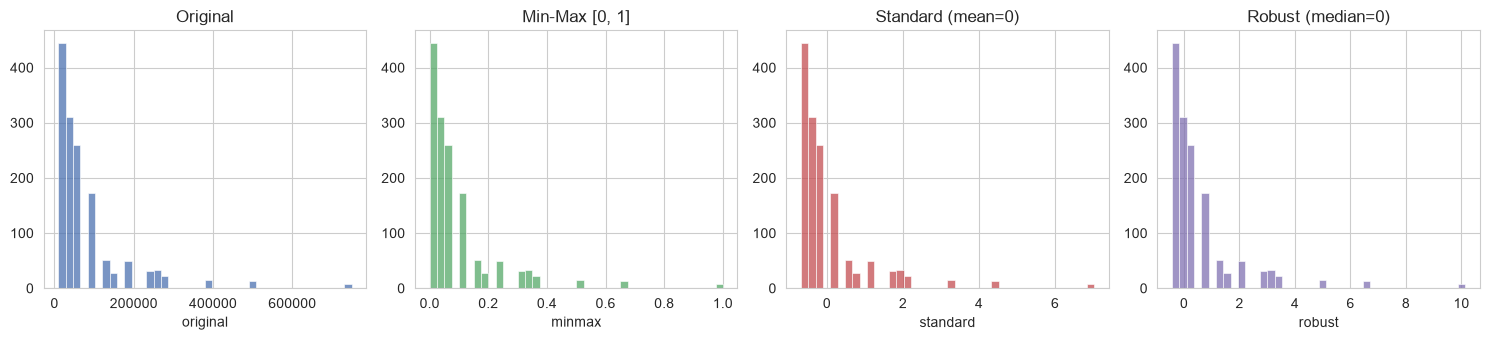

In [38]:
# 예제: 그림으로 비교 — 이상치가 있을 때 각 스케일러가 어떻게 반응하나
fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))
sns.histplot(scaled["original"], bins=40, ax=axes[0], color="#4C72B0")
axes[0].set_title("Original")

sns.histplot(scaled["minmax"], bins=40, ax=axes[1], color="#55A868")
axes[1].set_title("Min-Max [0, 1]")

sns.histplot(scaled["standard"], bins=40, ax=axes[2], color="#C44E52")
axes[2].set_title("Standard (mean=0)")

sns.histplot(scaled["robust"], bins=40, ax=axes[3], color="#8172B2")
axes[3].set_title("Robust (median=0)")

for ax in axes:
    ax.set_ylabel("")
plt.tight_layout(); plt.show()

In [39]:
# 예제: fit / transform 분리 — 실서비스의 정석
# 학습 데이터로 'fit'한 통계량을 새 데이터에도 똑같이 'transform'에 써야 합니다.
train = orders.iloc[:1000][["amount"]].dropna()
test  = orders.iloc[1000:][["amount"]].dropna()

scaler = StandardScaler()
scaler.fit(train)                              # train의 평균·표준편차를 기억
train_scaled = scaler.transform(train)         # 같은 기준으로 변환
test_scaled  = scaler.transform(test)          # test에도 같은 기준 적용

print("train 평균:", round(train_scaled.mean(), 3), "표준편차:", round(train_scaled.std(), 3))
print("test  평균:", round(test_scaled.mean(), 3),  "표준편차:", round(test_scaled.std(), 3))

train 평균: -0.0 표준편차: 1.0
test  평균: -0.022 표준편차: 0.922


   quantity  quantity_mm  quantity_robust
0         1     0.000000              0.0
1         3     0.025316              2.0
2         1     0.000000              0.0
3         1     0.000000              0.0
4         1     0.000000              0.0


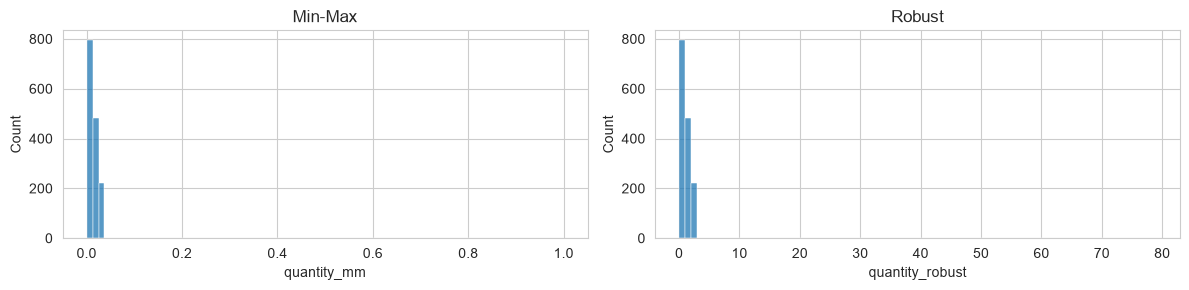

<Figure size 1000x500 with 0 Axes>

In [ ]:
# 스스로 해보자! (3)
from sklearn.preprocessing import MinMaxScaler, RobustScaler

qty = orders[["quantity"]]
orders["quantity_mm"] = MinMaxScaler().fit_transform(qty)
orders["quantity_robust"] = RobustScaler().fit_transform(qty)
print(orders[["quantity", "quantity_mm", "quantity_robust"]].head())


fig, axes = plt.subplots(1, 2, figsize=(12, 3))
sns.histplot(orders["quantity_mm"],     bins=30, ax=axes[0]); axes[0].set_title("Min-Max")
sns.histplot(orders["quantity_robust"], bins=30, ax=axes[1]); axes[1].set_title("Robust")
plt.tight_layout(); plt.show()
plt.tight_layout(); plt.show()

In [49]:
# 예제: '단계 변수'로 쓴 정제와 'chaining'으로 쓴 정제 — 결과는 같음

# (a) 단계 변수 방식 (전통)
step1 = orders.dropna(subset=["amount", "customer_age"])
step2 = step1[(step1["customer_age"] > 0) & (step1["customer_age"] < 120)]
step3 = step2.assign(
    region_clean=step2["region"].str.strip().replace({"Seoul": "서울"}),
    amount_log=np.log1p(step2["amount"]),
)
clean_a = step3.sort_values("amount", ascending=False).reset_index(drop=True)

# (b) method chaining 방식 (체이닝)
clean_b = (
    orders
    .dropna(subset=["amount", "customer_age"])
    .query("0 < customer_age < 120")
    .assign(
        region_clean=lambda d: d["region"].str.strip().replace({"Seoul": "서울"}),
        amount_log=lambda d: np.log1p(d["amount"]),
    )
    .sort_values("amount", ascending=False)
    .reset_index(drop=True)
)

# 두 결과가 같은가?
print("두 방식 결과 동일?:", clean_a.equals(clean_b))
print("정제 후 행 수:", clean_b.shape[0])
clean_b.head(3)

두 방식 결과 동일?: True
정제 후 행 수: 1411


,order_id,customer_age,region,membership,channel,category,price,quantity,amount,membership_score,...,membership_clean,channel_clean,membership_ord,ch_app,ch_web,ch_app,ch_web,quantity_mm,quantity_robust,amount_log
0,O00659,33.0,경기,basic,app,도서,249900.0,3,749700.0,1.0,...,basic,app,1,1,0,1,0,0.025316,2.0,13.52743
1,O00096,39.0,경기,silver,app,뷰티,249900.0,3,749700.0,2.0,...,silver,app,2,1,0,1,0,0.025316,2.0,13.52743
2,O00531,49.0,인천,basic,web,가전,249900.0,3,749700.0,1.0,...,basic,web,1,0,1,0,1,0.025316,2.0,13.52743


In [50]:
# 예제: query로 같은 필터 작성
# 1) 전통 방식
cond = (orders["customer_age"] > 0) & (orders["customer_age"] < 120) & (orders["amount"] >= 30000)
trad = orders[cond]

# 2) query 방식
q = orders.query("0 < customer_age < 120 and amount >= 30000")

print("동일?", trad.equals(q))
print("건수:", len(q))

동일? True
건수: 776


In [53]:
# 스스로 해보자! (4)
# 아래 빈칸(___)을 채우고 실행해보세요.

result = (
     orders
     .dropna(subset=["amount"]) # amount 결측 제거
     .query("0 < customer_age < 120") #customer_age가 0~120 사이인 행만 남기기
     .assign(
         channel_clean=lambda d: d["channel"].str.strip().str.lower(), #channel을 소문자·공백제거(channel_clean)
         amount_log=lambda d: np.log1p(d["amount"]), # amount_log = log1p(amount) 컬럼 추가
     )
     .sort_values("amount", ascending=False) #amount가 큰 순으로 정렬
     .reset_index(drop=True)
 )
print(result.shape)
result.head(3)

(1411, 23)


,order_id,customer_age,region,membership,channel,category,price,quantity,amount,membership_score,...,membership_clean,channel_clean,membership_ord,ch_app,ch_web,ch_app,ch_web,quantity_mm,quantity_robust,amount_log
0,O00659,33.0,경기,basic,app,도서,249900.0,3,749700.0,1.0,...,basic,app,1,1,0,1,0,0.025316,2.0,13.52743
1,O00096,39.0,경기,silver,app,뷰티,249900.0,3,749700.0,2.0,...,silver,app,2,1,0,1,0,0.025316,2.0,13.52743
2,O00531,49.0,인천,basic,web,가전,249900.0,3,749700.0,1.0,...,basic,web,1,0,1,0,1,0.025316,2.0,13.52743


In [54]:
# 예제: 단계마다 함수로 빼기 — '한 함수 = 한 책임'
def clean_strings(df):
    # 공백·대소문자·표기 혼재를 정리합니다.
    return df.assign(
        region=df["region"].str.strip().replace({"Seoul": "서울"}),
        membership=df["membership"].str.lower(),
        channel=df["channel"].str.strip().str.lower(),
    )

def drop_invalid(df, age_min=0, age_max=120, qty_max=20):
    # 불가능한 값(나이 범위·과대 수량)과 결측을 제거합니다.
    return (
        df
        .dropna(subset=["amount", "customer_age"])
        .query("@age_min < customer_age < @age_max")
        .query("quantity <= @qty_max")
    )

def add_features(df):
    # 분석에 쓸 파생 컬럼을 추가합니다.
    return df.assign(
        amount_log=lambda d: np.log1p(d["amount"]),
        is_premium=lambda d: d["membership"].isin(["gold", "vip"]).astype(int),
    )

print("세 함수가 준비됐습니다. 다음 셀에서 한 줄로 조립합니다.")

세 함수가 준비됐습니다. 다음 셀에서 한 줄로 조립합니다.


In [55]:
# 예제: 한 줄로 조립
cleaned = (
    orders
    .pipe(clean_strings)
    .pipe(drop_invalid, age_min=10, age_max=80, qty_max=10)
    .pipe(add_features)
)

print("원본:", orders.shape, "→ 정제 후:", cleaned.shape)
cleaned.head(3)

원본: (1500, 22) → 정제 후: (1404, 24)


,order_id,customer_age,region,membership,channel,category,price,quantity,amount,membership_score,...,channel_clean,membership_ord,ch_app,ch_web,ch_app,ch_web,quantity_mm,quantity_robust,amount_log,is_premium
1,O00002,24.0,대구,basic,app,가전,249900.0,3,749700.0,1.0,...,app,1,1,0,1,0,0.025316,2.0,13.527430,0
2,O00003,45.0,부산,basic,web,패션,19900.0,1,19900.0,1.0,...,web,1,0,1,0,1,0.000000,0.0,9.898525,0
4,O00005,41.0,서울,basic,app,패션,19900.0,1,19900.0,1.0,...,app,1,1,0,1,0,0.000000,0.0,9.898525,0


In [56]:
# 예제: 인코딩/스케일링 함수 추가
from sklearn.preprocessing import RobustScaler

def encode_categories(df):
    # membership은 Ordinal, region·channel·category는 One-Hot.
    order_map = {"basic": 1, "silver": 2, "gold": 3, "vip": 4}
    out = df.assign(membership_ord=df["membership"].map(order_map))
    # One-Hot
    out = pd.concat(
        [out,
         pd.get_dummies(out["region"], prefix="region", dtype=int),
         pd.get_dummies(out["channel"], prefix="ch", dtype=int),
         pd.get_dummies(out["category"], prefix="cat", dtype=int)],
        axis=1
    )
    return out

def scale_numeric(df, cols=("customer_age", "amount", "quantity")):
    # 수치형 컬럼을 RobustScaler로 스케일링.
    scaler = RobustScaler()
    scaled = scaler.fit_transform(df[list(cols)])
    scaled_df = pd.DataFrame(scaled, columns=[f"{c}_scaled" for c in cols], index=df.index)
    return pd.concat([df, scaled_df], axis=1)

# 전체 파이프라인 한 줄
pipeline_result = (
    orders
    .pipe(clean_strings)
    .pipe(drop_invalid, age_min=10, age_max=80, qty_max=10)
    .pipe(add_features)
    .pipe(encode_categories)
    .pipe(scale_numeric)
)

print("최종 shape:", pipeline_result.shape)
print("새로 생긴 컬럼 일부:", [c for c in pipeline_result.columns if "scaled" in c or c.startswith("region_")][:8])

최종 shape: (1404, 39)
새로 생긴 컬럼 일부: ['region_clean', 'region_경기', 'region_대구', 'region_부산', 'region_서울', 'region_인천', 'customer_age_scaled', 'amount_scaled']


In [ ]:
# 스스로 해보자! (5) 
# 위 clean_strings, drop_invalid, add_features 세 함수만 이용해 orders_v2를 만들어보세요.
# 새 함수 add_amount_class(df)를 만들어 amount >= 100000이면 'high', 그 외 'low'인 amount_class 컬럼을 추가하세요. 
# 그 함수를 파이프라인 마지막에 끼우세요.
# 같은 흐름을 함수가 아닌 chaining만으로 작성하면 어떤 점이 불편해질까요?
# ㄴ chaining만으로 작성하면, 각 단계에서 df를 재할당해야 하고, 중간 결과를 확인하기 어렵습니다. 
# 또한, 코드가 길어지고 가독성이 떨어지며, 재사용성이 낮아집니다. 함수로 나누면 각 단계의 책임이 명확해지고, 유지보수와 테스트가 용이해집니다.
def add_amount_class(df):
     return df.assign(
         amount_class=np.where(df["amount"] >= 100_000, "high", "low")
     )

orders_v2 = (
     orders
     .pipe(clean_strings)
     .pipe(drop_invalid)
     .pipe(add_features)
     .pipe(add_amount_class)   # 새 함수 끼우기
 )
print(orders_v2[["amount", "amount_class"]].head())
print(orders_v2["amount_class"].value_counts())

     amount amount_class
1  749700.0         high
2   19900.0          low
4   19900.0          low
6   59700.0          low
7  389700.0         high
amount_class
low     1162
high     248
Name: count, dtype: int64


In [58]:
# ─────────────────────────────────────────────
# 시나리오 0 — 원본 CSV 파일 준비 (실무에서는 외부에서 받아오는 단계)
# ─────────────────────────────────────────────
work_dir = Path("d006_work")
work_dir.mkdir(exist_ok=True)
input_csv  = work_dir / "orders_raw.csv"
output_csv = work_dir / "orders_clean.csv"

orders.to_csv(input_csv, index=False)
print("원본 CSV 저장:", input_csv, "—", input_csv.stat().st_size, "bytes")

원본 CSV 저장: d006_work\orders_raw.csv — 167154 bytes


In [59]:
# 시나리오 1 — 단계 함수들
def load_orders(path):
    # CSV에서 주문 데이터를 읽어 옵니다.
    return pd.read_csv(path)

def clean_strings_full(df):
    # 문자열 컬럼의 공백·대소문자·표기 혼재를 정리합니다.
    return df.assign(
        region=df["region"].str.strip().replace({"Seoul": "서울"}),
        membership=df["membership"].str.lower(),
        channel=df["channel"].str.strip().str.lower(),
    )

def drop_invalid_rows(df, age_min=10, age_max=80, qty_max=10):
    # 불가능한 값과 결측을 제거합니다.
    return (
        df
        .dropna(subset=["amount", "customer_age"])
        .query("@age_min < customer_age < @age_max")
        .query("quantity <= @qty_max")
        .drop_duplicates()
        .reset_index(drop=True)
    )

def add_derived(df):
    # 분석용 파생 컬럼을 추가합니다.
    return df.assign(
        amount_log=lambda d: np.log1p(d["amount"]),
        is_premium=lambda d: d["membership"].isin(["gold", "vip"]).astype(int),
        amount_class=lambda d: np.where(d["amount"] >= 100_000, "high",
                                np.where(d["amount"] >= 30_000, "mid", "low"))
    )

def encode_full(df):
    # membership=Ordinal, 나머지=One-Hot.
    order_map = {"basic": 1, "silver": 2, "gold": 3, "vip": 4}
    out = df.assign(membership_ord=df["membership"].map(order_map))
    one_hots = [
        pd.get_dummies(out["region"],   prefix="region", dtype=int),
        pd.get_dummies(out["channel"],  prefix="ch",     dtype=int),
        pd.get_dummies(out["category"], prefix="cat",    dtype=int),
    ]
    return pd.concat([out] + one_hots, axis=1)

def scale_with_robust(df, cols=("customer_age", "amount", "quantity")):
    # 수치형 컬럼을 Robust로 스케일링하고 _scaled 접미사를 붙입니다.
    scaler = RobustScaler()
    scaled = scaler.fit_transform(df[list(cols)])
    scaled_df = pd.DataFrame(scaled,
                             columns=[f"{c}_scaled" for c in cols],
                             index=df.index)
    return pd.concat([df, scaled_df], axis=1)

print("단계 함수 6개 정의 완료. 다음 셀에서 한 줄로 조립합니다.")

단계 함수 6개 정의 완료. 다음 셀에서 한 줄로 조립합니다.


In [74]:
# 시나리오 2 — end-to-end 파이프라인
def preprocess(input_path):
    # 원본 CSV 경로를 받아 전처리된 DataFrame을 돌려줍니다.
    return (
        load_orders(input_path)
        .pipe(clean_strings_full)
        .pipe(drop_invalid_rows, age_min=10, age_max=80, qty_max=10)
        .pipe(add_derived)
        .pipe(encode_full)
        .pipe(scale_with_robust)
    )

# 진짜 한 줄 호출
clean_df = preprocess(input_csv)
print("입력 행 수 → 출력 행 수:", orders.shape[0], "→", clean_df.shape[0])
print("출력 컬럼 수:", clean_df.shape[1])
clean_df.head(3)

입력 행 수 → 출력 행 수: 1500 → 1404
출력 컬럼 수: 40


,order_id,customer_age,region,membership,channel,category,price,quantity,amount,membership_score,...,ch_app,ch_web,cat_가전,cat_도서,cat_뷰티,cat_식품,cat_패션,customer_age_scaled,amount_scaled,quantity_scaled
0,O00002,24.0,대구,basic,app,가전,249900.0,3,749700.0,1.0,...,1,0,1,0,0,0,0,-0.916667,10.141429,2.0
1,O00003,45.0,부산,basic,web,패션,19900.0,1,19900.0,1.0,...,0,1,0,0,0,0,1,0.833333,-0.284286,0.0
2,O00005,41.0,서울,basic,app,패션,19900.0,1,19900.0,1.0,...,1,0,0,0,0,0,1,0.500000,-0.284286,0.0


In [65]:
# 시나리오 3 — 저장 + 재로드 검증
clean_df.to_csv(output_csv, index=False)

reloaded = pd.read_csv(output_csv)
print("저장 파일:", output_csv, "—", output_csv.stat().st_size, "bytes")
print("저장 직전 shape:", clean_df.shape)
print("다시 읽은  shape:", reloaded.shape)
print("동일한가?:", clean_df.shape == reloaded.shape)

저장 파일: d006_work\orders_clean.csv — 275620 bytes
저장 직전 shape: (1404, 40)
다시 읽은  shape: (1404, 40)
동일한가?: True


In [1]:
# 품질 리포트 함수
def quality_report(before: pd.DataFrame, after: pd.DataFrame) -> dict:
    # 전처리 전·후 데이터의 품질 차이를 dict로 반환합니다.
    report = {
        "rows_before": before.shape[0], # 입력 행 수
        "rows_after":  after.shape[0], # 출력 행 수
        "removed_pct": round(100 * (1 - after.shape[0] / before.shape[0]), 2), # 제거된 비율
        "cols_before": before.shape[1], # 입력 컬럼 수
        "cols_after":  after.shape[1], # 출력 컬럼 수
        "new_cols":    after.shape[1] - before.shape[1], # 추가된 컬럼 수
        "missing_top5_before": ( # 결측이 많은 상위 5개 컬럼
            before.isnull().sum().sort_values(ascending=False).head(5).to_dict()
        ),
        "missing_top5_after": ( # 
            after.isnull().sum().sort_values(ascending=False).head(5).to_dict()
        ),
        "dtypes_after": after.dtypes.value_counts().to_dict(), # 출력 데이터 타입 분포
    }
    return report

# 사용
rep = quality_report(orders, clean_df)
for k, v in rep.items():
    print(f"{k}: {v}")
print("최종 shape:", rep["rows_after"])
print("새로 생긴 컬럼 일부:", [c for c in clean_df.columns if "scaled" in c or c.startswith("region_")][:8])

NameError: name 'pd' is not defined

In [63]:
# 코드 퀴즈 — 모범 답안
top5 = (
    orders
    .dropna(subset=["amount"])
    .assign(region=lambda d: d["region"].str.strip())
    .query("10 < customer_age < 80")
    .assign(amount_log=lambda d: np.log1p(d["amount"]))
    .sort_values("amount_log", ascending=False)
    .head(5)
)
print(top5[["region", "customer_age", "amount", "amount_log"]])

     region  customer_age    amount  amount_log
1        대구          24.0  749700.0    13.52743
658      경기          33.0  749700.0    13.52743
530      인천          49.0  749700.0    13.52743
1081     서울          36.0  749700.0    13.52743
95       경기          39.0  749700.0    13.52743
